In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain.messages import RemoveMessage
import os

In [3]:
load_dotenv()

True

In [4]:
llm= HuggingFaceEndpoint(
    repo_id='deepseek-ai/DeepSeek-V3.1-Terminus',
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
)


model= ChatHuggingFace(llm=llm)

In [5]:

from typing import TypedDict
from langchain_core.messages import BaseMessage
from typing_extensions import Annotated
from langgraph.graph.message import add_messages


class MessagesState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [6]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [8]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [9]:
graph = builder.compile(checkpointer=InMemorySaver())

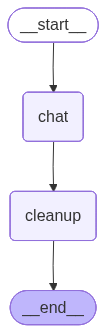

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

In [12]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='04597378-cbd3-437c-9984-a25a26bb144b'),
  AIMessage(content='Of course! Let\'s break down **LangChain**.\n\n### The Core Idea: A Framework for LLM Applications\n\nIn simple terms, **LangChain** is an open-source framework that helps developers build applications powered by Large Language Models (LLMs). It provides the tools and abstractions to go beyond a simple API call to an LLM (like OpenAI\'s GPT-4) and create complex, powerful, and context-aware applications.\n\nThink of it like this: Using an LLM\'s API directly is like having a incredibly smart, but amnesiac and unskilled, assistant. You have to give it all the context every single time, and it can only use its own knowledge.\n\nLangChain provides this assistant with:\n*   **A memory** to remember past conversations.\n*   **A set of tools** (like a calculator, a web browser, or a database connection) so it can take action.\n* 

In [13]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
